In [7]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [8]:
BASE_PATH = "/kaggle/input/datasets/murtozalikhon/brain-tumor-multimodal-image-ct-and-mri/Dataset"

CT_PATH = os.path.join(BASE_PATH, "Brain Tumor CT scan Images")
MRI_PATH = os.path.join(BASE_PATH, "Brain Tumor MRI images")

IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 20

print(os.listdir(BASE_PATH))
print(os.listdir(CT_PATH))
print(os.listdir(MRI_PATH))

['Brain Tumor MRI images', 'Brain Tumor CT scan Images']
['Tumor', 'Healthy', 'CT image source.txt']
['Tumor', 'Healthy', 'MRI image source.txt']


In [11]:
def load_images(folder_path):
    images = []
    labels = []

    for class_name in ["Healthy", "Tumor"]:
        class_path = os.path.join(folder_path, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img / 255.0

            images.append(img)
            labels.append(class_name)

    return np.array(images), np.array(labels)

In [12]:
ct_images, ct_labels = load_images(CT_PATH)
mri_images, mri_labels = load_images(MRI_PATH)

print("CT Images:", ct_images.shape)
print("CT Labels:", ct_labels.shape)

print("MRI Images:", mri_images.shape)
print("MRI Labels:", mri_labels.shape)

CT Images: (4618, 128, 128, 3)
CT Labels: (4618,)
MRI Images: (5000, 128, 128, 3)
MRI Labels: (5000,)


In [13]:
min_samples = min(len(ct_images), len(mri_images))

ct_images = ct_images[:min_samples]
ct_labels = ct_labels[:min_samples]

mri_images = mri_images[:min_samples]
mri_labels = mri_labels[:min_samples]

labels = ct_labels

print("Final CT:", ct_images.shape)
print("Final MRI:", mri_images.shape)
print("Final Labels:", labels.shape)

Final CT: (4618, 128, 128, 3)
Final MRI: (4618, 128, 128, 3)
Final Labels: (4618,)


In [14]:
encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

num_classes = len(encoder.classes_)
labels_categorical = tf.keras.utils.to_categorical(labels_encoded, num_classes)

print("Classes:", encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['Healthy' 'Tumor']
Number of classes: 2


In [15]:
X_ct_train, X_ct_test, X_mri_train, X_mri_test, y_train, y_test = train_test_split(
    ct_images,
    mri_images,
    labels_categorical,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

print("CT Train:", X_ct_train.shape)
print("MRI Train:", X_mri_train.shape)
print("Y Train:", y_train.shape)

CT Train: (3694, 128, 128, 3)
MRI Train: (3694, 128, 128, 3)
Y Train: (3694, 2)


In [16]:
def cnn_branch(input_shape):
    input_layer = Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu')(input_layer)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)

    return input_layer, x

In [17]:
ct_input, ct_features = cnn_branch((IMG_SIZE, IMG_SIZE, 3))
mri_input, mri_features = cnn_branch((IMG_SIZE, IMG_SIZE, 3))

combined = layers.Concatenate()([ct_features, mri_features])

x = layers.Dense(128, activation='relu')(combined)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=[ct_input, mri_input], outputs=output)

model.summary()

I0000 00:00:1779989335.202516      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779989335.208259      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 126, 126,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 63, 63,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 30, 30,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 14, 14,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 25088)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  3,211,392 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │  3,211,392 │ flatten_1[0][0] 

 Total params: 6,650,562 (25.37 MB)

 Trainable params: 6,650,562 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    [X_ct_train, X_mri_train],
    y_train,
    validation_data=([X_ct_test, X_mri_test], y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/20


I0000 00:00:1779989372.456234     173 service.cc:152] XLA service 0x7e37f40072c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779989372.456297     173 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779989372.456304     173 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779989373.147027     173 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-28 17:29:34.850024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 17:29:34.994516: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/231 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4763 - loss: 0.7998

I0000 00:00:1779989377.866906     173 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7707 - loss: 0.4455

2026-05-28 17:29:43.317949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-28 17:29:43.463489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.8706 - loss: 0.2967 - val_accuracy: 0.9459 - val_loss: 0.1385
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9475 - loss: 0.1333 - val_accuracy: 0.9459 - val_loss: 0.1362
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9656 - loss: 0.0935 - val_accuracy: 0.9610 - val_loss: 0.0926
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9718 - loss: 0.0712 - val_accuracy: 0.9675 - val_loss: 0.0970
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9821 - loss: 0.0558 - val_accuracy: 0.9643 - val_loss: 0.0953
Epoch 6/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9848 - loss: 0.0402 - val_accuracy: 0.9740 - val_loss: 0.0912
Epoch 7/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9875 - loss: 0.0334 - val_accuracy: 0.9621 - val_loss: 0.1090
Epoch 8/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9911 - loss: 0.0199 - val_accuracy: 0.97

In [20]:
loss, accuracy = model.evaluate([X_ct_test, X_mri_test], y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9708 - loss: 0.2682
Test Loss: 0.2681722640991211
Test Accuracy: 0.9707792401313782


In [24]:
import matplotlib.pyplot as plt

def predict_multimodal(ct_image_path, mri_image_path):
    ct_img_original = cv2.imread(ct_image_path)
    ct_img_rgb = cv2.cvtColor(ct_img_original, cv2.COLOR_BGR2RGB)

    ct_img = cv2.resize(ct_img_rgb, (IMG_SIZE, IMG_SIZE))
    ct_img = ct_img / 255.0
    ct_img = np.expand_dims(ct_img, axis=0)

    mri_img_original = cv2.imread(mri_image_path)
    mri_img_rgb = cv2.cvtColor(mri_img_original, cv2.COLOR_BGR2RGB)

    mri_img = cv2.resize(mri_img_rgb, (IMG_SIZE, IMG_SIZE))
    mri_img = mri_img / 255.0
    mri_img = np.expand_dims(mri_img, axis=0)

    prediction = model.predict([ct_img, mri_img])
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(ct_img_rgb)
    plt.title("CT Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mri_img_rgb)
    plt.title("MRI Image")
    plt.axis("off")

    plt.suptitle(
        f"Prediction: {encoder.classes_[predicted_class]} | Confidence: {confidence:.2f}",
        fontsize=14
    )

    plt.show()

    print("Predicted Class:", encoder.classes_[predicted_class])
    print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


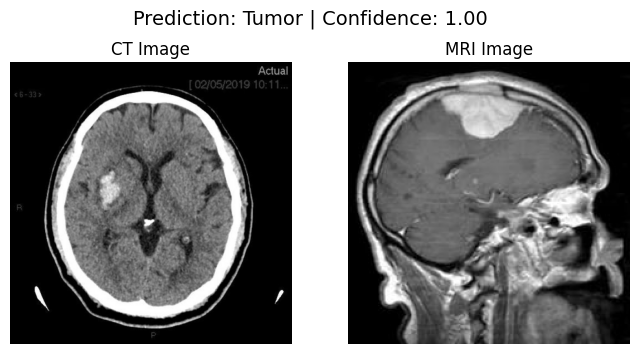

Predicted Class: Tumor
Confidence: 1.0


In [25]:
ct_test_image = os.path.join(CT_PATH, "Tumor", os.listdir(os.path.join(CT_PATH, "Tumor"))[0])
mri_test_image = os.path.join(MRI_PATH, "Tumor", os.listdir(os.path.join(MRI_PATH, "Tumor"))[0])

predict_multimodal(ct_test_image, mri_test_image)